In [9]:
import torch
import pandas as pd

df = pd.read_csv('/home/hjj747/deepLearning/nn/classify_3c_5k.csv')
print(df.head())

data = df[['x', 'y']].values
labels = df['label'].values

print(f"Data shape: {data.shape}")
print(f"Labels shape: {labels.shape}")

          x         y  label
0  0.097627  0.430379      1
1  0.205527  0.089766      2
2 -0.152690  0.291788      1
3 -0.124826  0.783546      0
4  0.927326 -0.233117      0
Data shape: (5000, 2)
Labels shape: (5000,)


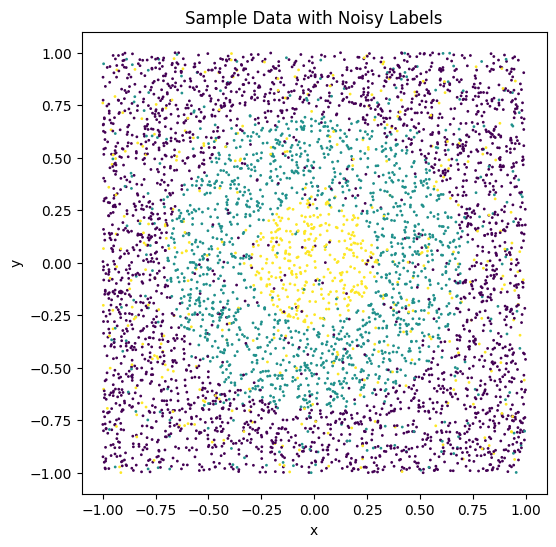

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', s=1)
plt.title('Sample Data with Noisy Labels')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [35]:
# PyTorch tensor 형태로 변환
data_torch = torch.tensor(data, dtype=torch.float32)
labels_torch = torch.tensor(labels, dtype=torch.long)

data_length = len(data_torch)
split_length = int(0.8 * data_length)

# Train-validation split
train_data = data_torch[:split_length]
train_labels = labels_torch[:split_length]
val_data = data_torch[split_length:]
val_labels = labels_torch[split_length:]

print(f"Train data shape: {train_data.shape},  Train data type: {train_data.dtype}")
print(f"Train labels shape: {train_labels.shape},  Train labels type: {train_labels.dtype}")
print(f"Validation data shape: {val_data.shape},  Validation data type: {val_data.dtype}")
print(f"Validation labels shape: {val_labels.shape},  Validation labels type: {val_labels.dtype}")

Train data shape: torch.Size([4000, 2]),  Train data type: torch.float32
Train labels shape: torch.Size([4000]),  Train labels type: torch.int64
Validation data shape: torch.Size([1000, 2]),  Validation data type: torch.float32
Validation labels shape: torch.Size([1000]),  Validation labels type: torch.int64


In [36]:
g = torch.Generator().manual_seed(42)

# 배치 사이즈 만큼 데이터를 무작위로 선택하여 반환하는 함수
def get_batch(data, labels, batch_size=256):

    indices = torch.randint(0, len(data), size=(batch_size,), generator=g)

    data_batch = data[indices]
    labels_batch = labels[indices]

    return data_batch, labels_batch

data_batch, labels_batch = get_batch(train_data, train_labels)
print(f"Data batch shape: {data_batch.shape},  Data batch type: {data_batch.dtype}")
print(f"Labels batch shape: {labels_batch.shape},  Labels batch type: {labels_batch.dtype}")

Data batch shape: torch.Size([256, 2]),  Data batch type: torch.float32
Labels batch shape: torch.Size([256]),  Labels batch type: torch.int64


In [23]:
# custom Cross-Entropy loss function
def custom_cross_entropy_loss(output, one_hot_label):
    exp_output = torch.exp(output)
    total = torch.sum(exp_output, dim=1, keepdim=True)
    softmax_output = exp_output / total
    log_prob = -torch.log(softmax_output)
    nll = (log_prob * one_hot_label).sum(dim=1)
    return torch.mean(nll)

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim


# DNN의 입력, 은닉층, 출력층 크기 설정
input_size = 2
hidden_size = 4
output_size = 3

# 무작위 시드 설정
g.manual_seed(42)
torch.manual_seed(42)

# DNN 모델 정의
class Net(nn.Module):

    # DNN의 초기화 함수 정의 (선형 계층과 활성화 함수 설정)
    def __init__(self):
        super().__init__()

        # DNN의 계층을 순차적으로 정의 (선형 계층과 ReLU 활성화 함수 사용)
        self.seq_model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    # DNN의 forward 함수 정의 (ReLU 활성화 함수 사용)
    def forward(self, x : torch.Tensor) -> torch.Tensor:
        return self.seq_model(x)

# DNN 모델 인스턴스 생성
net = Net()

# CrossEntropyLoss 함수 정의 (이 함수는 내부적으로 소프트맥스 함수를 적용하므로, output을 그대로 사용)
lossfn = nn.CrossEntropyLoss()

# SGD 옵티마이저 정의 (모델의 모든 매개변수를 업데이트하도록 설정)
optimizer = optim.SGD(net.parameters(), lr=0.01)



# 간단한 DNN 연산과 손실 계산
for steps in range(100000):
    net.train
    # 무작위로 선택된 배치에 대해 DNN 연산 수행
    data_batch, labels_batch = get_batch(train_data, train_labels, batch_size=256)
    output = net(data_batch)
    
    # CrossEntropyLoss를 사용하여 손실 계산 (이 함수는 내부적으로 소프트맥스 함수를 적용하므로, output을 그대로 사용)
    loss = lossfn(output, labels_batch)

    optimizer.zero_grad()   # 옵티마이저의 기울기 초기화 (다음 스텝을 위해)
    loss.backward()         # 역전파 수행
    optimizer.step()        # 옵티마이저 스텝 수행 (모델의 매개변수 업데이트)
    

    # 1000 스텝마다 학습 손실과 검증 손실 계산 및 출력
    if steps % 1000 == 0:
        net.eval()          # DNN을 평가 모드로 설정 (예: 드롭아웃과 배치 정규화가 있는 경우, 이 모드에서는 이를 비활성화)
        output = net(val_data)
        val_loss = lossfn(output, val_labels)
        print(f"Step: {steps}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")
        net.train()         # DNN을 학습 모드로 다시 설정 (예: 드롭아웃과 배치 정규화가 있는 경우, 이 모드에서는 이를 활성화)


# 출력 형태 확인
print(f"Output shape: {output.shape}")

Step: 0, Train Loss: 1.1170, Val Loss: 1.1057
Step: 1000, Train Loss: 0.9350, Val Loss: 0.9680
Step: 2000, Train Loss: 0.9479, Val Loss: 0.9686
Step: 3000, Train Loss: 0.9467, Val Loss: 0.9681
Step: 4000, Train Loss: 0.9426, Val Loss: 0.9674
Step: 5000, Train Loss: 0.9968, Val Loss: 0.9667
Step: 6000, Train Loss: 0.9217, Val Loss: 0.9647
Step: 7000, Train Loss: 0.9021, Val Loss: 0.9616
Step: 8000, Train Loss: 0.9401, Val Loss: 0.9560
Step: 9000, Train Loss: 0.9518, Val Loss: 0.9474
Step: 10000, Train Loss: 0.9268, Val Loss: 0.9326
Step: 11000, Train Loss: 0.9227, Val Loss: 0.9057
Step: 12000, Train Loss: 0.8146, Val Loss: 0.8420
Step: 13000, Train Loss: 0.8164, Val Loss: 0.7782
Step: 14000, Train Loss: 0.7583, Val Loss: 0.7531
Step: 15000, Train Loss: 0.7535, Val Loss: 0.7425
Step: 16000, Train Loss: 0.7068, Val Loss: 0.7379
Step: 17000, Train Loss: 0.7160, Val Loss: 0.7345
Step: 18000, Train Loss: 0.8292, Val Loss: 0.7331
Step: 19000, Train Loss: 0.7085, Val Loss: 0.7328
Step: 20000, 

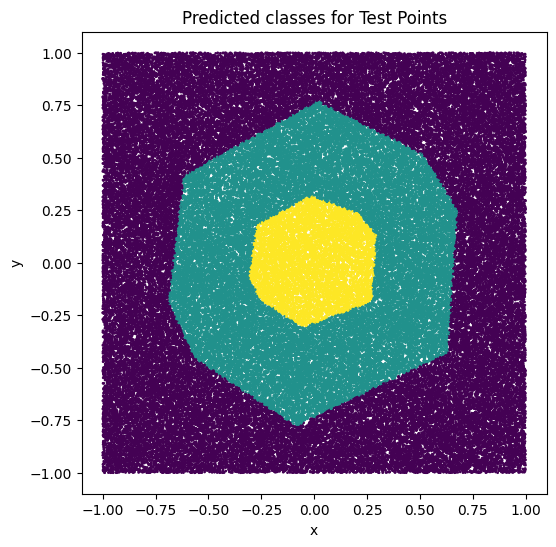

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# 테스트용 무작위 점 생성
n_points_test = 100000
points_test = np.random.uniform(-1, 1, (n_points_test, 2))
points_test_torch = torch.from_numpy(points_test).float()

net.eval()                                  # DNN을 평가 모드로 설정
output_test = net(points_test_torch)        # DNN을 사용하여 테스트 점에 대한 출력을 계산

pred = torch.argmax(output_test, dim=1).numpy()  # 가장 높은 출력을 가진 클래스 인덱스를 예측값으로 사용

# 예측된 클래스 시각화
plt.figure(figsize=(6, 6))
plt.scatter(points_test[:, 0], points_test[:, 1], c=pred, cmap='viridis', s=1)
plt.title('Predicted classes for Test Points')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


In [13]:
import torch
import torch.nn.functional as F

categories = torch.tensor([0, 2, 1, 3])
one_hot = F.one_hot(categories)
print(one_hot)

tensor([[1, 0, 0, 0],
        [0, 0, 1, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 1]])


In [14]:
import torch.nn.functional as F

data_torch = torch.tensor(data, dtype=torch.float32)
labels_torch = torch.tensor(labels)
print(f"before onde-hot encoding: {labels_torch.shape}")

num_classes = len(labels_torch.unique())
labels_torch = F.one_hot(labels_torch, num_classes)
print(f"after one-hot encoding: {labels_torch.shape}")

before onde-hot encoding: torch.Size([5000])
after one-hot encoding: torch.Size([5000, 3])
